In [6]:
import pandas as pd
data_path = 'mexico-real-estate-combined-clean.csv'
real_estate_df = pd.read_csv(data_path)
real_estate_df.head()

,property_type,price_aprox_usd,surface_covered_in_m2,state,lat,lon
0,apartment,289775.66,54.0,Distrito Federal,23.634501,-102.552788
1,house,79661.96,80.0,Distrito Federal,19.310330,-99.068557
2,apartment,48822.82,100.0,Distrito Federal,19.279771,-99.234597
3,apartment,337720.36,135.0,Distrito Federal,23.634501,-102.552788
4,apartment,875000.00,263.0,Quintana Roo,21.190264,-86.819838


In [7]:
import matplotlib.pyplot as plt
import numpy as np

Text(0, 0.5, 'Frequency')

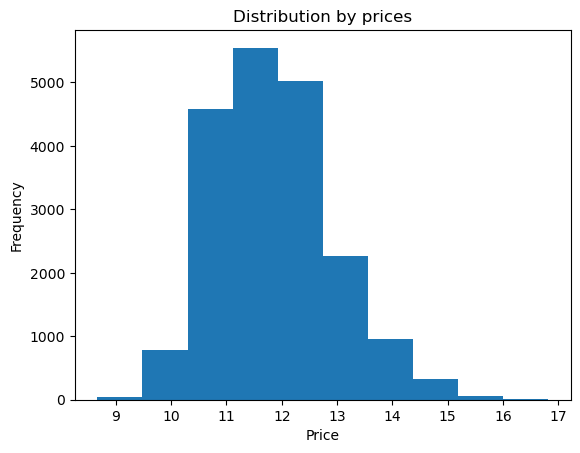

In [8]:
fig,ax=plt.subplots()
ax.hist(np.log1p(real_estate_df['price_aprox_usd'])) # We take log of price to better visualize the distribution we take log1p because log can't handle 0 but log1p(x) can because it handles 1+x
ax.set_title('Distribution by prices')
ax.set_xlabel('Price')
ax.set_ylabel('Frequency')

Text(0.5, 0, 'Total Surface Area')

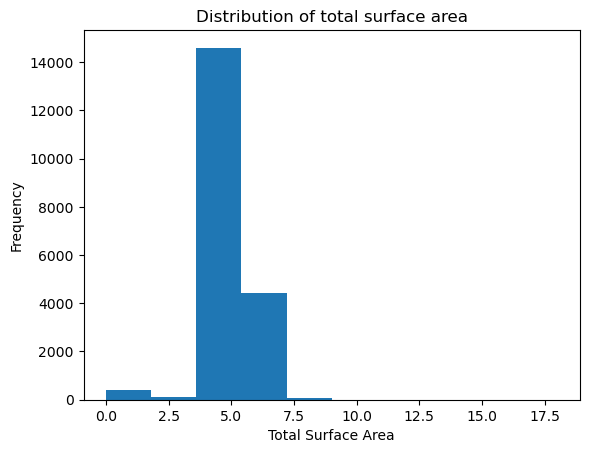

In [9]:
fig,ax=plt.subplots()
ax.hist(np.log1p(real_estate_df['surface_covered_in_m2']))
ax.set_title('Distribution of total surface area')
ax.set_ylabel('Frequency')
ax.set_xlabel('Total Surface Area')

C:\Users\Acer\AppData\Local\Temp\ipykernel_10332\40063131.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_by_type,labels=property_types)


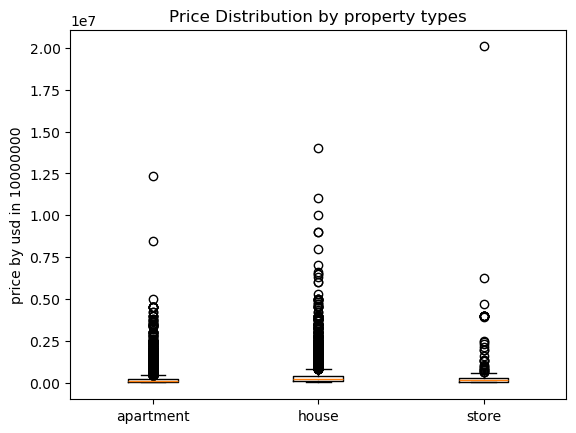

In [10]:
property_types=real_estate_df['property_type'].unique()
data_by_type=[real_estate_df[real_estate_df['property_type']== type]["price_aprox_usd"] for type in property_types]
fig,ax=plt.subplots()
ax.boxplot(data_by_type,labels=property_types)
ax.set_title('Price Distribution by property types')
ax.set_ylabel('price by usd in 10000000')
plt.show()

Text(0.5, 0, 'Price of usd in 10000000')

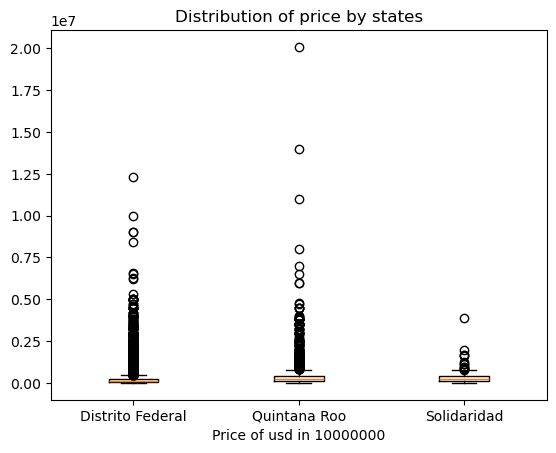

In [11]:
topstates=(real_estate_df['state']
    .value_counts()
    .head(3)
    .index.tolist())

data_state=[real_estate_df[real_estate_df['state']==state]["price_aprox_usd"] for state in topstates]
fig, ax= plt.subplots()
ax.boxplot(data_state,tick_labels=topstates)
ax.set_title("Distribution of price by states")
ax.set_xlabel("Price of usd in 10000000")

In [12]:
lower_limit=0.05
upper_limit=0.95
df= real_estate_df
df_clean=(
    df[
        (df["price_aprox_usd"]>df["price_aprox_usd"].quantile(lower_limit)) &
        (df["price_aprox_usd"]<df["price_aprox_usd"].quantile(upper_limit)) &
        (df["surface_covered_in_m2"]>df["surface_covered_in_m2"].quantile(lower_limit)) &
        (df["surface_covered_in_m2"]<df["surface_covered_in_m2"].quantile(upper_limit)) 
    ]
    )

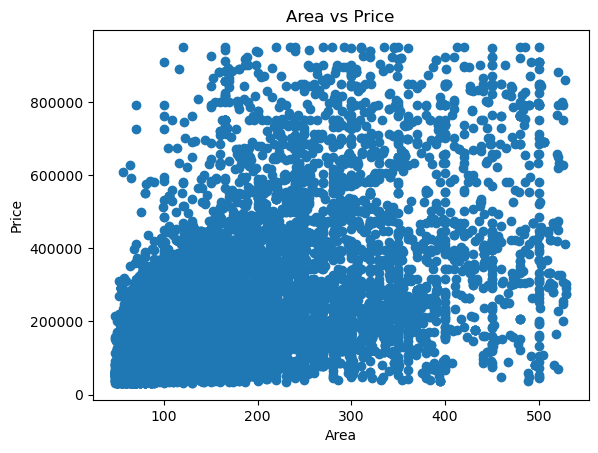

In [13]:
fig, ax= plt.subplots()
ax.scatter(df_clean['surface_covered_in_m2'],df_clean['price_aprox_usd'])
ax.set_title('Area vs Price')
ax.set_xlabel('Area')
ax.set_ylabel('Price')
plt.show()

<Axes: xlabel='surface_covered_in_m2', ylabel='price_aprox_usd'>

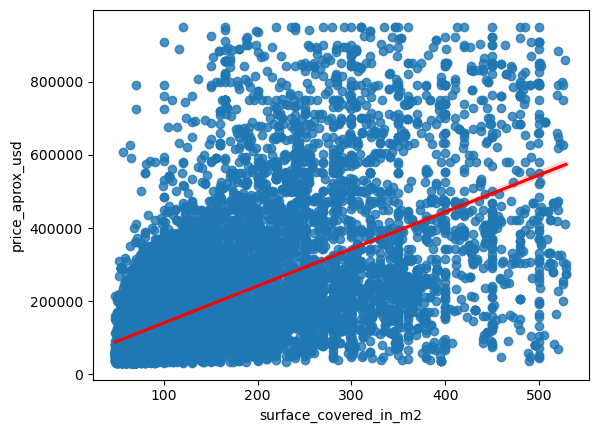

In [14]:
import seaborn as sns
fig,ax= plt.subplots()
sns.regplot(
    data=df_clean,
    x="surface_covered_in_m2",
    y='price_aprox_usd',
    line_kws={'color':'red'},
)


In [15]:
mean_state=df.groupby('state')['price_aprox_usd'].mean().sort_values()

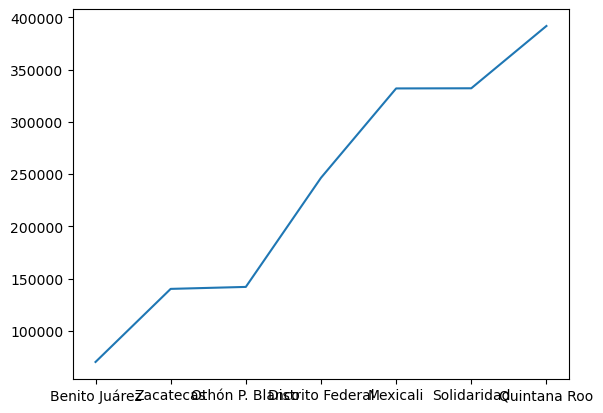

In [16]:
fig,ax=plt.subplots()
ax.plot(mean_state)

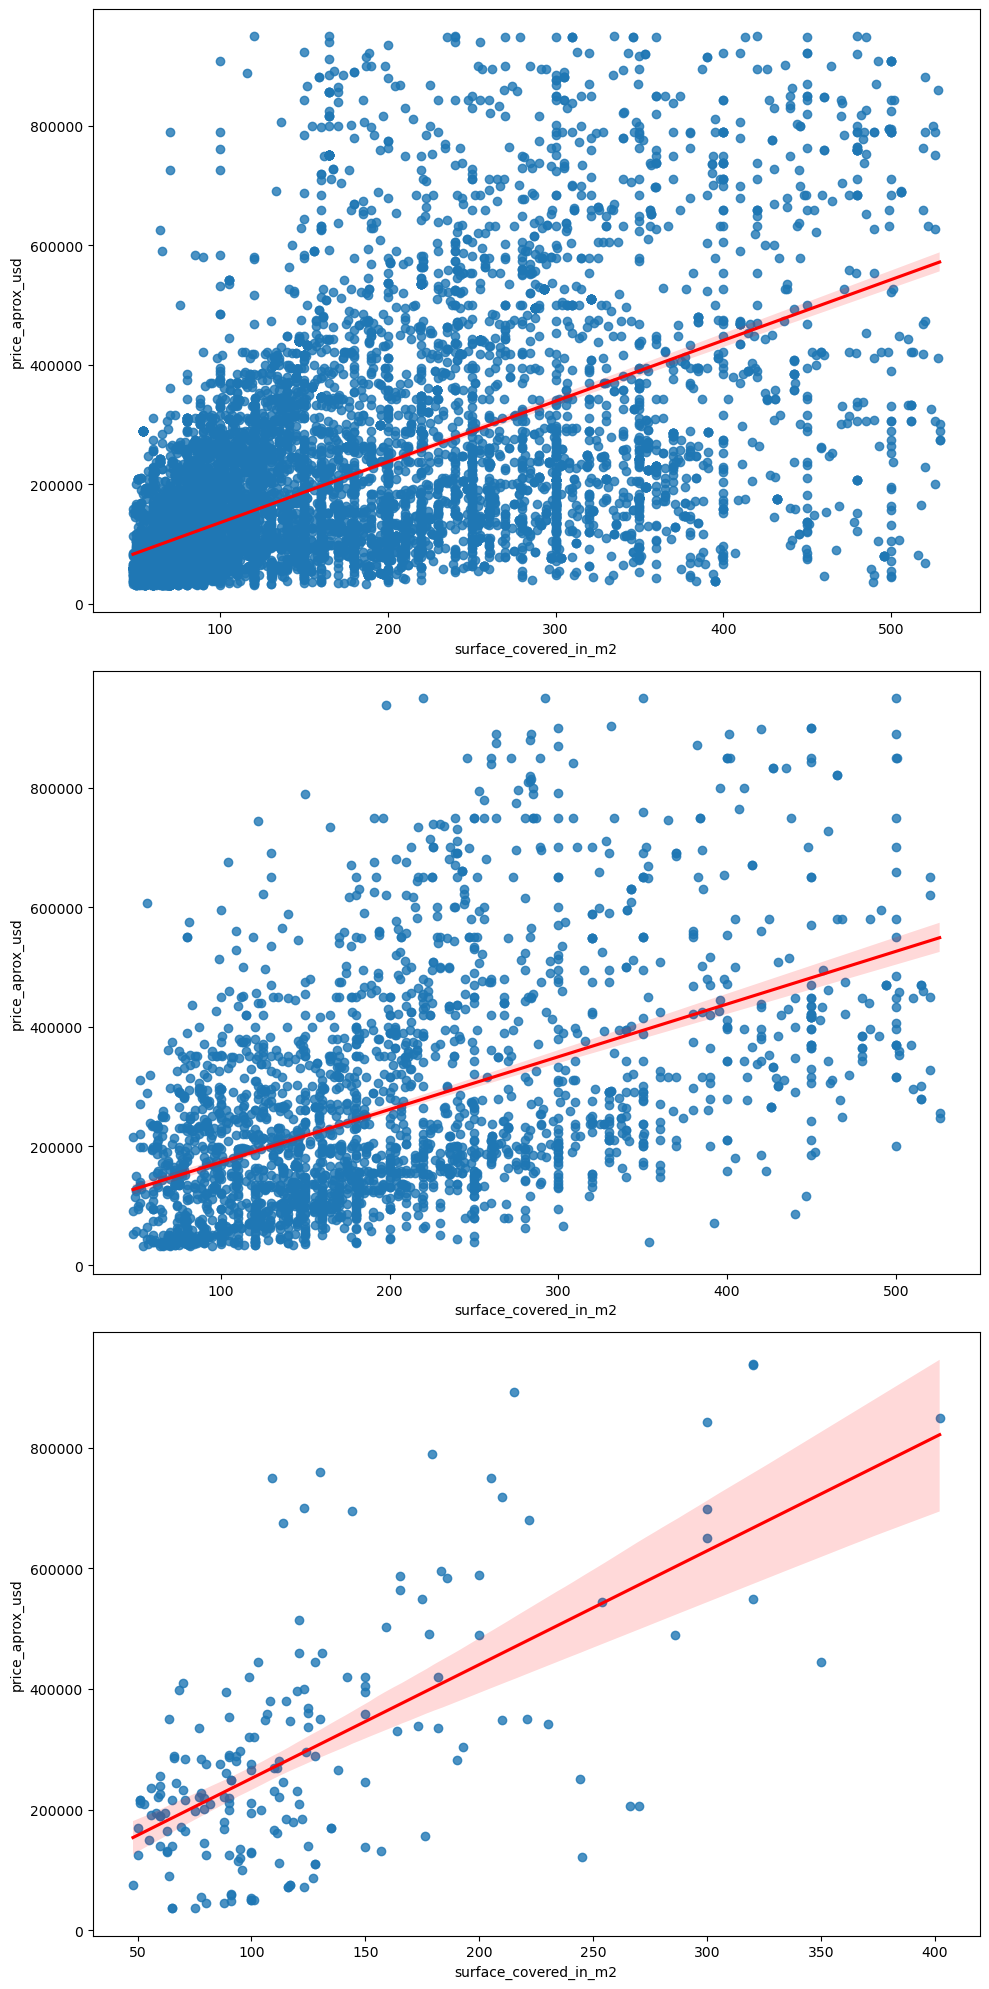

In [17]:
fig, axes= plt.subplots(3,1,figsize=(10,20))
df_states=df_clean[df_clean['state'].isin(topstates)]
states=df['state'].unique()
for ax, state in zip(axes,states):
    sample=df_clean[df_clean['state']==state]
    sns.regplot(
        data=sample,
        x="surface_covered_in_m2",
        y='price_aprox_usd',
        line_kws={'color':'red'},
        ax=ax
        )
plt.tight_layout()
plt.show()